In [3]:
import cv2, numpy as np, requests, keras_ocr

def read_url_with_header(url: str):
    headers = {"User-Agent": "Mozilla/5.0"}
    r = requests.get(url, headers=headers, timeout=20)
    r.raise_for_status()
    arr = np.frombuffer(r.content, np.uint8)
    img = cv2.imdecode(arr, cv2.IMREAD_COLOR)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

pipeline = keras_ocr.pipeline.Pipeline()

urls = [
    "https://upload.wikimedia.org/wikipedia/commons/b/bd/Army_Reserves_Recruitment_Banner_MOD_45156284.jpg",
    # 기존 e/e8/FseeG2QeLXo.jpg 는 404라 제거
    "https://upload.wikimedia.org/wikipedia/commons/b/b4/EUBanana-500x112.jpg",
]

images = []
for u in urls:
    try:
        images.append(read_url_with_header(u))
    except Exception as e:
        print(f"skip: {u} ({e})")

prediction_groups = pipeline.recognize(images)

Looking for C:\Users\user\.keras-ocr\craft_mlt_25k.h5
Looking for C:\Users\user\.keras-ocr\crnn_kurapan.h5
2/2 [==============================] - 2s 104ms/step


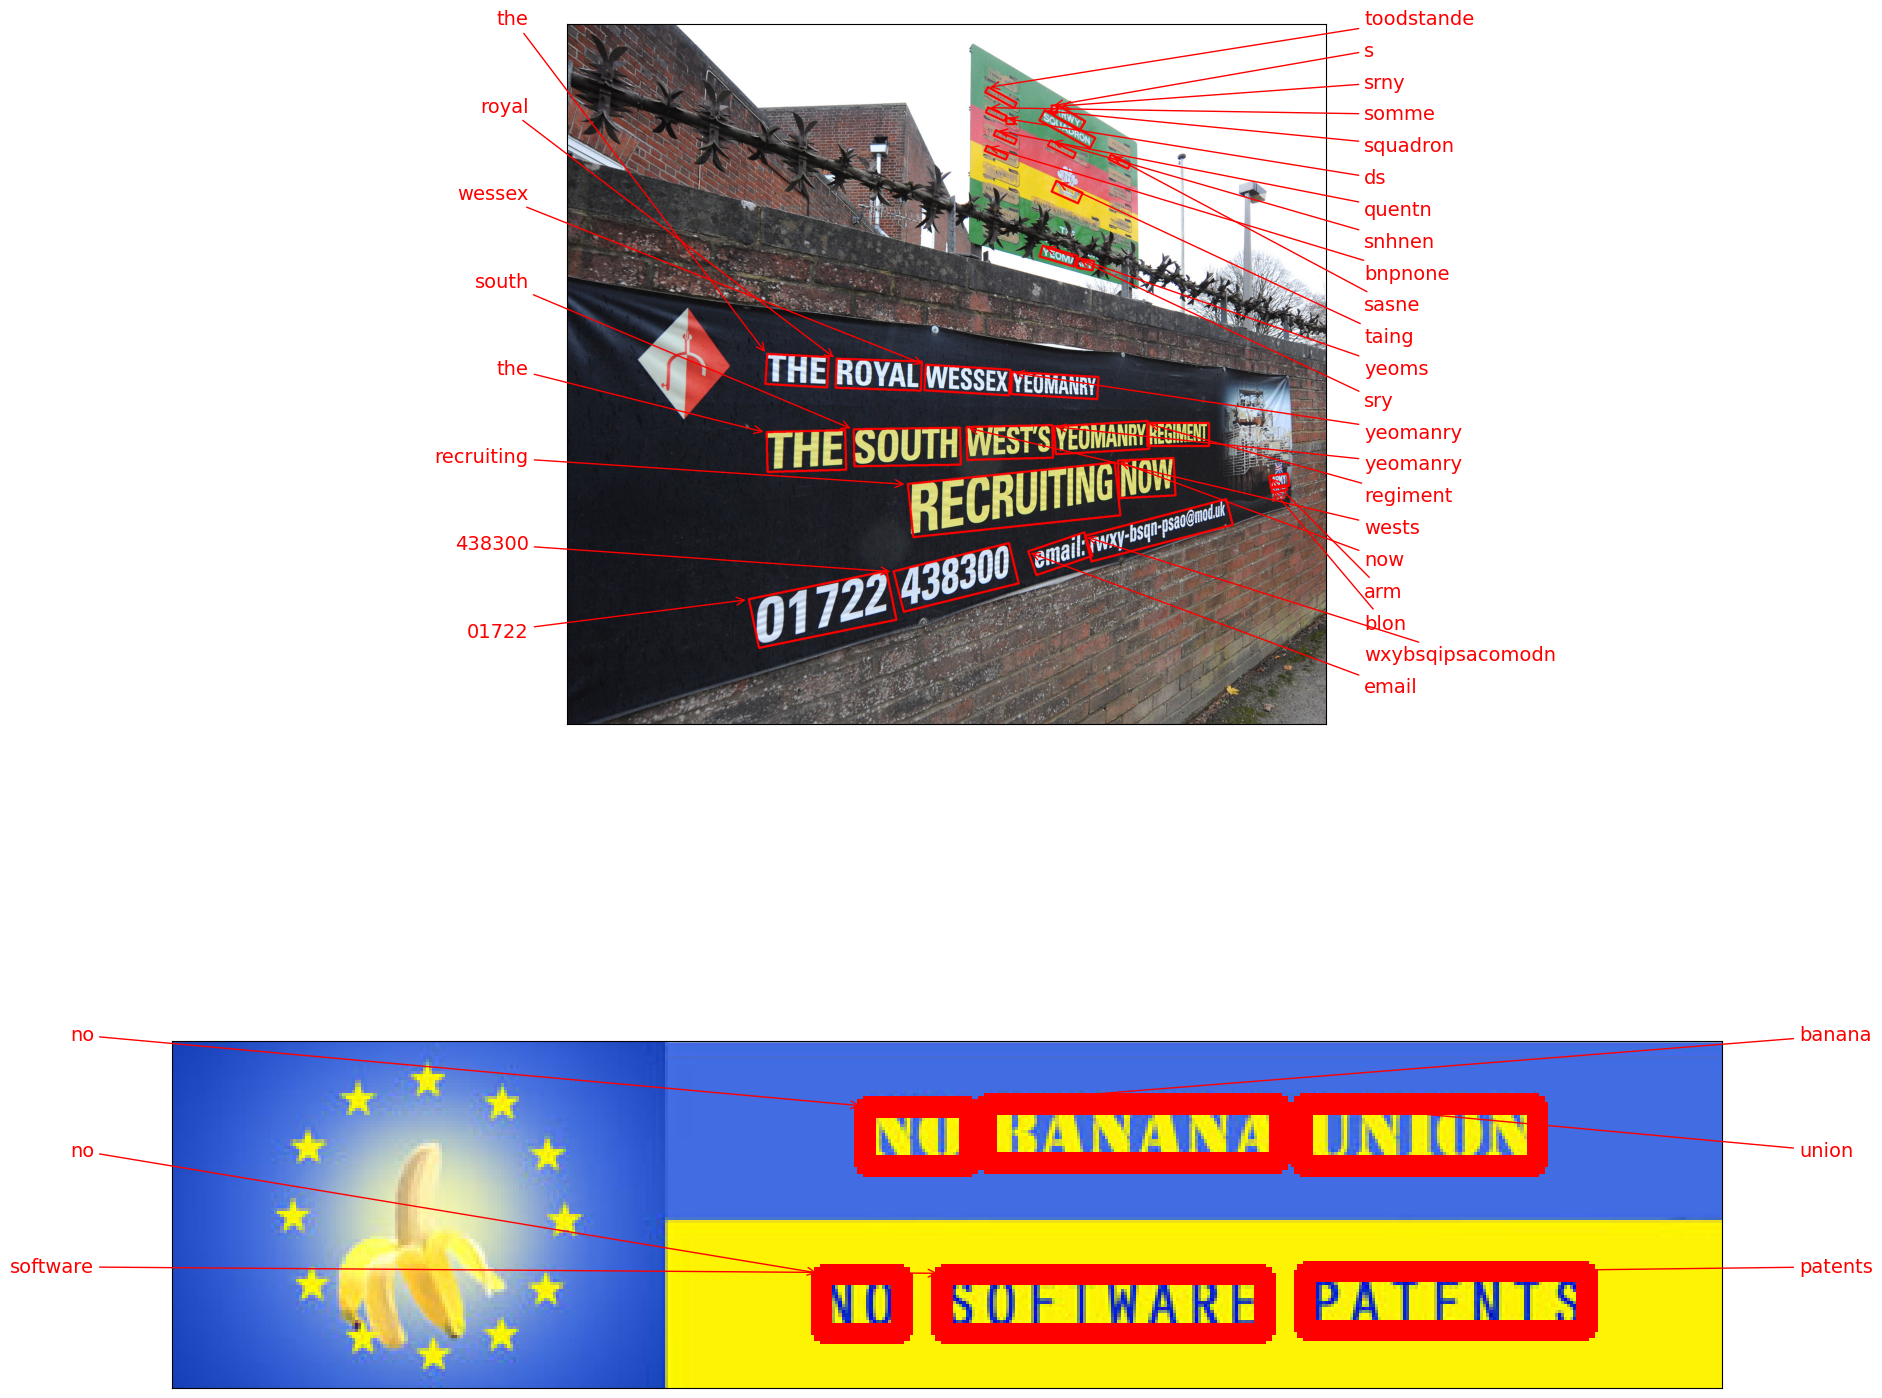

In [4]:
# Plot the predictions
fig, axs = plt.subplots(nrows=len(images), figsize=(20, 20))
for ax, image, predictions in zip(axs, images, prediction_groups):
    keras_ocr.tools.drawAnnotations(image=image, predictions=predictions, ax=ax)